# DenseNet usage in DEGANN

#### This notebook demonstrates how to create and train a DenseNet using DEGANN.

**Import necessary libraries:**

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from degann.equations.system_ode import SystemODE
from degann.equations.equation_utils import system_ode_from_string
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from degann.networks.topology.DenseNet.parameter_space import DenseNetParameterSpace
from degann.networks.topology.DenseNet.tf_densenet import TensorflowDenseNet
from degann.search_algorithms.grid_search import grid_search
from degann.search_algorithms.random_search import random_search
from degann.search_algorithms.simulated_annealing import simulated_annealing

%matplotlib inline

**Prepare data for training:**

In [5]:
f = "y0**2-2*y0+1 y0(0)=0.5"
f_prep = system_ode_from_string(f)
f = SystemODE()
f.prepare_equations(1, f_prep)
f.solve((0, 5), 1000)
data = f.build_table()
X, y = data[:, 0].reshape(-1, 1), data[:, 1].reshape(-1, 1)

In [6]:
def plot_diff_grid(t_new, y_new, y_pred):
    plt.figure(figsize=(12, 6))
    plt.plot(t_new, y_new, 'b-', linewidth=2, label='True solution', alpha=0.7)
    plt.plot(t_new, y_pred, 'r--', linewidth=2, label='NN predictions', alpha=0.7)
    plt.xlabel('t', fontsize=12)
    plt.ylabel('y(t)', fontsize=12)
    plt.title('Model Generalization on Different Grid', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

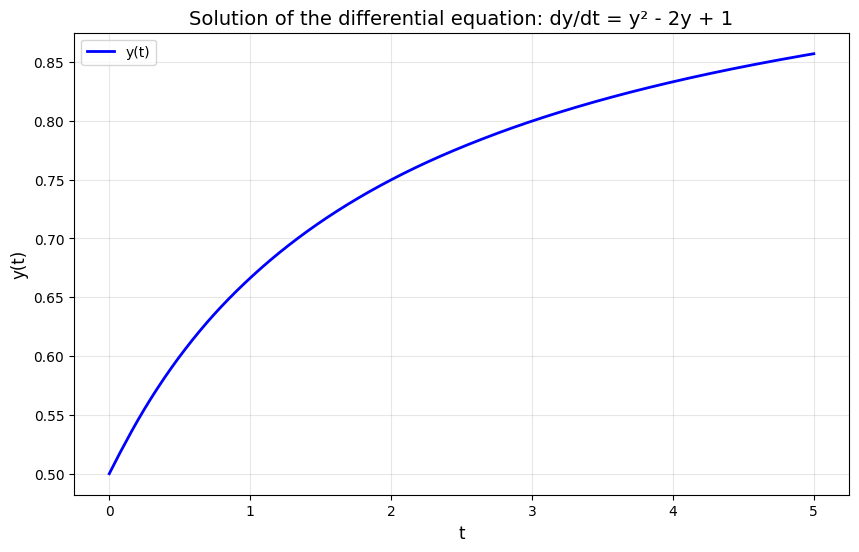

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(X, y, 'b-', linewidth=2, label='y(t)')
plt.xlabel('t', fontsize=12)
plt.ylabel('y(t)', fontsize=12)
plt.title('Solution of the differential equation: dy/dt = y² - 2y + 1', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Define and create paramter object for DenseNet:**

In [8]:
denseNN_params = DenseNetParameterSpace(
    input_size=1,
    output_size=1,
    optimizers=["SGD", "Adam"],
    losses=["MeanSquaredError", "MeanAbsoluteError"],
    epochs=[10, 15],
    nn_min_depth=2,
    nn_max_depth=3,
    layer_sizes=[8, 16],
    activation_funcs=["sigmoid", "tanh"]
)

**Grid search**

In [9]:
grid_loss, grid_epoch, grid_loss_name, grid_optimizer, grid_nn = grid_search(
    data=(X, y),
    params=denseNN_params,
    verbose=True
)

1 2026-05-10 21:07:43
2 2026-05-10 21:07:45
3 2026-05-10 21:07:46
4 2026-05-10 21:07:49
5 2026-05-10 21:07:51
6 2026-05-10 21:07:53
7 2026-05-10 21:07:55
8 2026-05-10 21:07:58
9 2026-05-10 21:08:01
10 2026-05-10 21:08:02
11 2026-05-10 21:08:03
12 2026-05-10 21:08:06
13 2026-05-10 21:08:09
14 2026-05-10 21:08:10
15 2026-05-10 21:08:12
16 2026-05-10 21:08:15
17 2026-05-10 21:08:18
18 2026-05-10 21:08:20
19 2026-05-10 21:08:21
20 2026-05-10 21:08:24
21 2026-05-10 21:08:27
22 2026-05-10 21:08:28
23 2026-05-10 21:08:30
24 2026-05-10 21:08:32
25 2026-05-10 21:08:35
26 2026-05-10 21:08:37
27 2026-05-10 21:08:38
28 2026-05-10 21:08:41
29 2026-05-10 21:08:43
30 2026-05-10 21:08:45
31 2026-05-10 21:08:47
32 2026-05-10 21:08:50
33 2026-05-10 21:08:53
34 2026-05-10 21:08:55
35 2026-05-10 21:08:56
36 2026-05-10 21:08:59
37 2026-05-10 21:09:01
38 2026-05-10 21:09:03
39 2026-05-10 21:09:05
40 2026-05-10 21:09:08
41 2026-05-10 21:09:12
42 2026-05-10 21:09:14
43 2026-05-10 21:09:15
44 2026-05-10 21:09:

In [10]:
print(f"Loss: {grid_loss}")
print(f"Layers: {grid_nn['config']['layer_sizes']}")
print(f"Activations: {grid_nn['config']['activation_funcs'][:-1]}")
print(f"Optimizer: {grid_optimizer}")
print(f"Loss function: {grid_loss_name}")

Loss: 3.5426228350843303e-07
Layers: [8, 16, 16]
Activations: ['tanh', 'tanh', 'tanh']
Optimizer: Adam
Loss function: MeanSquaredError


In [11]:
nn = TensorflowDenseNet.from_dict(grid_nn)

**To assess the model's generalization capability, we now consider a distinct set of points across the same interval and examine the prediction accuracy.**

In [12]:
# Create a new set of points with different sampling frequency
t_new = np.linspace(0, 5, 500).reshape(-1, 1)  # different grid resolution

# Solve the ODE on the new grid points
f.solve((0, 5), 500)
data_new = f.build_table()
X_new, y_new = data_new[:, 0].reshape(-1, 1), data_new[:, 1].reshape(-1, 1)

# Obtain model predictions on the new grid
y_pred = nn(t_new)

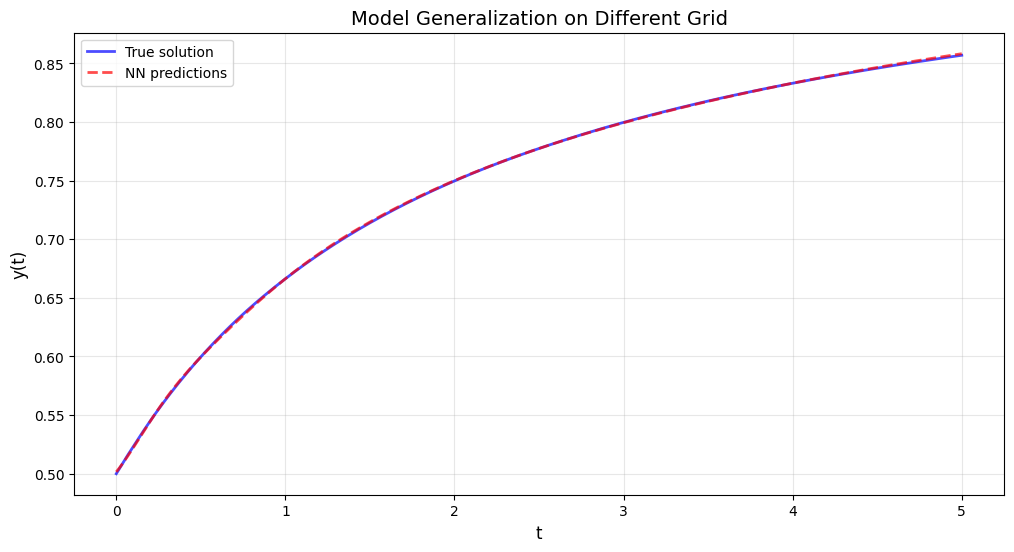

In [13]:
plot_diff_grid(t_new, y_new, y_pred)

In [14]:
mse = mean_squared_error(y_new, y_pred)
print(f"MSE on new grid: {mse}")

MSE on new grid: 3.2276745013587037e-07


**Random search**

In [19]:
random_loss, random_epoch, random_loss_name, random_optimizer, random_nn = random_search(
    data=(X, y),
    params=denseNN_params,
    iterations=25,
    verbose=True
)

1/25 2026-05-10 21:33:34
2/25 2026-05-10 21:33:37
3/25 2026-05-10 21:33:38
4/25 2026-05-10 21:33:39
5/25 2026-05-10 21:33:41
6/25 2026-05-10 21:33:43
7/25 2026-05-10 21:33:46
8/25 2026-05-10 21:33:48
9/25 2026-05-10 21:33:50
10/25 2026-05-10 21:33:56
11/25 2026-05-10 21:33:58
12/25 2026-05-10 21:34:00
13/25 2026-05-10 21:34:03
14/25 2026-05-10 21:34:06
15/25 2026-05-10 21:34:07
16/25 2026-05-10 21:34:11
17/25 2026-05-10 21:34:14
18/25 2026-05-10 21:34:16
19/25 2026-05-10 21:34:17
20/25 2026-05-10 21:34:20
21/25 2026-05-10 21:34:23
22/25 2026-05-10 21:34:25
23/25 2026-05-10 21:34:28
24/25 2026-05-10 21:34:29
25/25 2026-05-10 21:34:31


In [20]:
print(f"Loss: {random_loss}")
print(f"Layers: {random_nn['config']['layer_sizes']}")
print(f"Activations: {random_nn['config']['activation_funcs'][:-1]}")
print(f"Optimizer: {random_optimizer}")
print(f"Loss function: {random_loss_name}")

Loss: 1.0802226597661502e-06
Layers: [8, 8, 8]
Activations: ['tanh', 'tanh', 'sigmoid']
Optimizer: Adam
Loss function: MeanSquaredError


In [21]:
nn1 = TensorflowDenseNet.from_dict(random_nn)
y_pred = nn1(t_new)

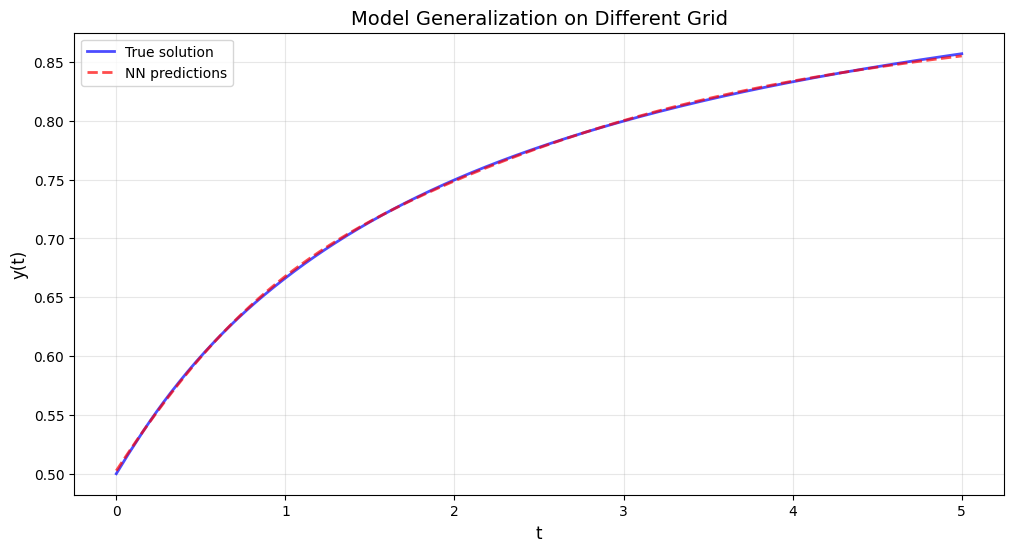

In [22]:
plot_diff_grid(t_new, y_new, y_pred)

In [23]:
mse = mean_squared_error(y_new, y_pred)
print(f"MSE on new grid: {mse}")

MSE on new grid: 7.247864299301866e-07


**Simulated annealing algorithm**

In [24]:
sim_loss, sim_epochs, sim_loss_name, sim_optimizer, sim_nn, sim_iter = simulated_annealing(
    data=(X, y),
    params=denseNN_params,
    max_iter=15,
    threshold=1e-5,
    verbose=True
)

1/15 2026-05-10 21:34:55
2/15 2026-05-10 21:34:57
3/15 2026-05-10 21:35:00
4/15 2026-05-10 21:35:01
5/15 2026-05-10 21:35:03
6/15 2026-05-10 21:35:05
7/15 2026-05-10 21:35:08
8/15 2026-05-10 21:35:10
9/15 2026-05-10 21:35:13
10/15 2026-05-10 21:35:15
11/15 2026-05-10 21:35:18
12/15 2026-05-10 21:35:21


In [25]:
print(f"Loss: {sim_loss}")
print(f"Layers: {sim_nn['config']['layer_sizes']}")
print(f"Activations: {sim_nn['config']['activation_funcs'][:-1]}")
print(f"Optimizer: {sim_optimizer}")
print(f"Loss function: {sim_loss_name}")
print(f"Iterations: {sim_iter}")

Loss: 3.5374293929635314e-06
Layers: [8, 8]
Activations: ['tanh', 'tanh']
Optimizer: Adam
Loss function: MeanSquaredError
Iterations: 12


In [26]:
nn2 = TensorflowDenseNet.from_dict(sim_nn)
y_pred = nn2(t_new)

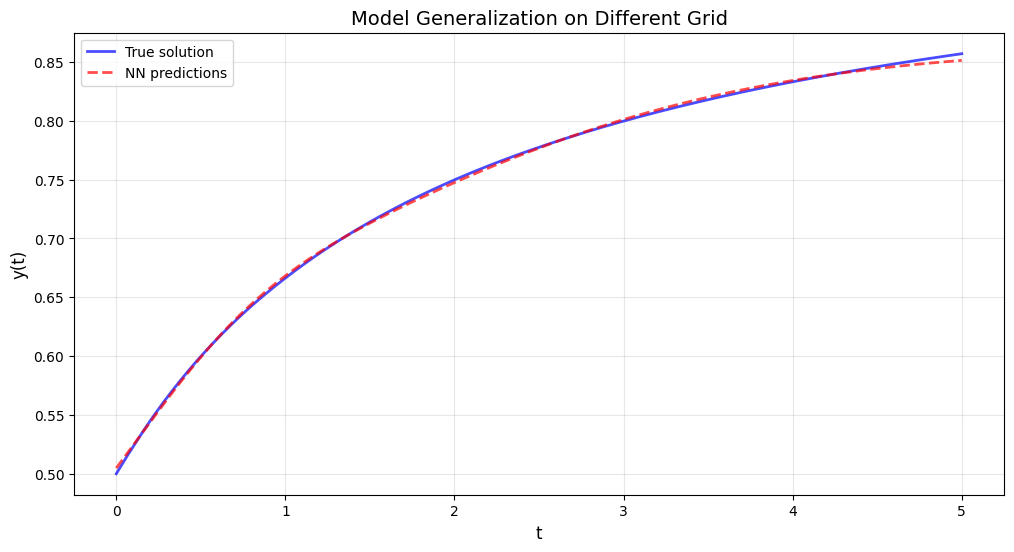

In [27]:
plot_diff_grid(t_new, y_new, y_pred)

In [28]:
mse = mean_squared_error(y_new, y_pred)
print(f"MSE on new grid: {mse}")

MSE on new grid: 3.501233399988123e-06
